In [1]:
import numpy as np
import pandas as pd
import jax
import jax.numpy as jnp
import jax.random as jr
import optax
import time
import matplotlib.pyplot as plt

In [2]:
tau = [jnp.linspace(0, 20, 41),
       jnp.linspace(0, 20, 41)]

hyperparameters = {
    "theta" : jnp.array([0.2, 0.2, 3.0]),
    "X0" : jnp.array([-1.0, 1.0]),
    "sigma" : jnp.array([0.2, 0.2]),
    "tau" : tau,
    # "obs_times" : test_helpers.obs_matrix(tau),
    "I" : jnp.linspace(0, 20, int(160 +1))
}

def ode(X, theta, t=None):
    '''
    X : n x D
    theta : p

    return : n x D
    '''
    n = X.shape[0]
    V, R = X.T
    a, b, c = theta # theta.repeat([n, 1]).T

    return jnp.stack([c * (V - V**3/3 + R),
                        -1/c * (V - a + b*R)])

In [3]:
data = pd.read_csv('y.csv').to_numpy()
I = np.arange(0, 20.1, 0.125)
full = np.full((I.shape[0], data.shape[1]), np.nan)
full[:,0] = I
full[np.isin(full[:,0], data[:,0])] = data

# full[:,2] = np.nan
# pd.DataFrame(full).to_csv('y_disc.csv', index=False)

In [4]:
from magi import MAGI

In [5]:
# jax.config.update("jax_default_matmul_precision", "highest")

In [6]:
dtype = jnp.float32

start = time.time()
solver = MAGI(ode, full, [1, 1, 1], theta_conf=[0,0,0], sigmas=[0.2, 0.2])

solver.put(dtype, jax.devices()[0])

solver.solve(k=200, sigma_init=0.2, mitosis_splits=2, optimizer_kwargs={'learning_rate': 5e-3}, atol=0.1, rtol=0, max_iter=400)
end = time.time()
print(f"Elapsed time: {end - start:.4f}")

/home/jamie/miniforge3/envs/jax-cuda13/lib/python3.14/site-packages/jax/_src/numpy/util.py:84: UserWarning: Explicitly requested dtype int64 requested in dtype is not available, and will be truncated to dtype int32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  to_dtype, weak_type = dtypes.lattice_result_type(*args)


Split 0 finished after 400 iterations | max grad = 12.97204
Split 1 finished after 400 iterations | max grad = 13414.39941
Split 2 finished after 400 iterations | max grad = 5447352.00000
Elapsed time: 13.8006


In [13]:
solver.particles = None
start = time.time()
thetas, Xs, sigmas = solver.solve(k=200, sigma_init=0.01, mitosis_splits=2, optimizer_kwargs={'learning_rate': 0.01}, atol=0.1, rtol=0, max_iter=1000)
end = time.time()
print(f"Elapsed time: {end - start:.4f}")

Split 0 finished after 1000 iterations | max grad = 3.27937
Split 1 finished after 1000 iterations | max grad = 0.77987
Split 2 finished after 1000 iterations | max grad = 18.05000
Elapsed time: 0.7715


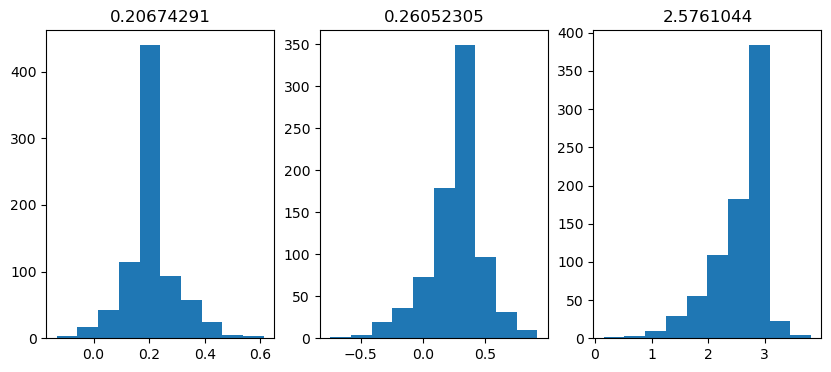

In [14]:
fig, ax = plt.subplots(1, 3, figsize=(10, 4))
for i in range(3):
    ax[i].hist(thetas[:,i])
    ax[i].set_title(thetas[:,i].mean())

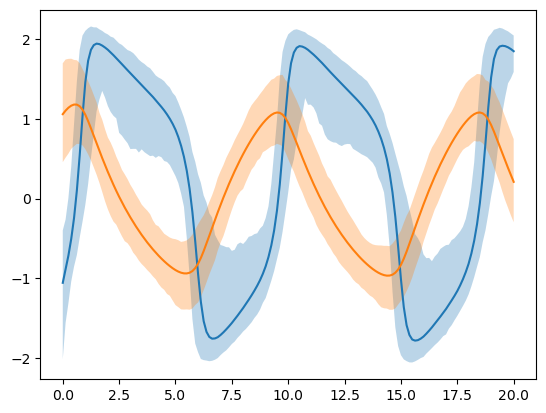

In [15]:
plt.fill_between(solver.I.flatten(), jnp.quantile(Xs[:,:,0], 0.025, axis=0), jnp.quantile(Xs[:,:,0], 0.975, axis=0), alpha=0.3)
plt.plot(solver.I, Xs.mean(axis=0)[:,0])

plt.fill_between(solver.I.flatten(), jnp.quantile(Xs[:,:,1], 0.025, axis=0), jnp.quantile(Xs[:,:,1], 0.975, axis=0), alpha=0.3)
plt.plot(solver.I, Xs.mean(axis=0)[:,1])

In [187]:
solver.phis

Array([[2.1334085 , 1.3102835 ],
       [0.45490193, 2.0049021 ]], dtype=float32)

In [188]:
solver.K_invs.mean()

Array(277.1057, dtype=float32)

In [189]:
diags = [jnp.diag(c) for c in solver.K_invs]

In [190]:
particles = solver.particles
theta = particles[:,:solver.p] # (p,)
X = jnp.reshape(particles[:,solver.p:solver.p+solver.D*solver.n], (particles.shape[0], solver.n, solver.D)) # (n, d)
# sigmas = solver.sigmas.at[:,solver.unknown_sigmas].set(jnp.clip(particles[:,solver.p+solver.D*solver.n:], min=1e-5)) # (d,)

In [191]:
particles.shape

(1600, 325)

In [192]:
theta.mean(axis=0)

Array([0.23620404, 0.34558004, 2.823209  ], dtype=float32)

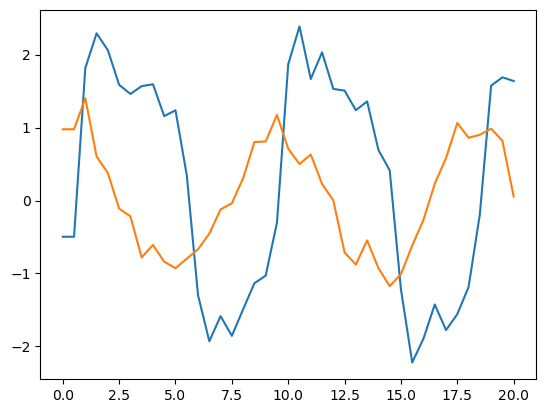

In [193]:
plt.plot(solver.I,  jnp.reshape(solver.particles_init[solver.p:solver.p+solver.D*solver.n], (solver.n, solver.D)) )

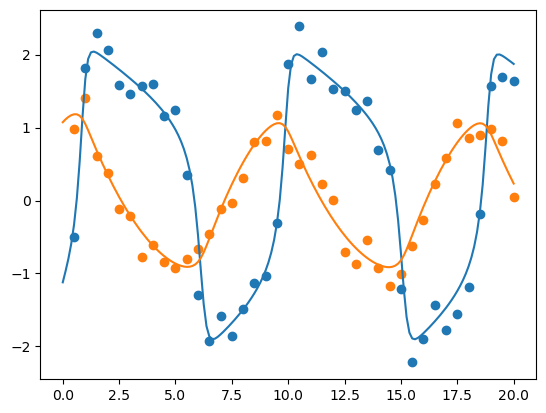

In [194]:
plt.plot(solver.I, X.mean(axis=0)[:,0])
plt.plot(solver.I, X.mean(axis=0)[:,1])
plt.scatter(data[:,0], data[:,1])
plt.scatter(data[:,0], data[:,2])